In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_mfcc(segmented_dir, n_mfcc=13, hop_length=512):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                n_fft = min(2048, len(signal))
                mfcc = librosa.feature.mfcc(y=signal, 
                                            sr=sr, 
                                            n_mfcc=n_mfcc, 
                                            n_fft=n_fft, 
                                            hop_length=hop_length)
                # mfcc_db = librosa.power_to_db(mfcc**2)
                # mfcc_list.append(mfcc_db)
                X.append(mfcc)
                y.append(label)

    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [3]:
X, y, label_encoder = create_mfcc('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [08:33<00:00, 46.67s/it]


Plot MFCC

In [4]:
def plot_mfcc(X, i=0):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.show()

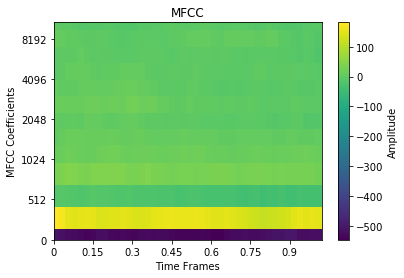

In [5]:
plot_mfcc(X)

CNN model

In [6]:
# cnn = models.Sequential([
#     layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(len(musical_instruments), activation='softmax')
# ])

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 13, 44, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 13, 44, 32)        128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 7, 22, 32)         0         
_________________________________________________________________
dropout (Dropout)            (None, 7, 22, 32)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 7, 22, 64)         18496     
_________________________________________________________________
batch_normalization_1 (Batch (None, 7, 22, 64)         256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 11, 64)         0

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
403/403 [==============================] - 20s 49ms/step - loss: 2.2173 - accuracy: 0.2300 - val_loss: 2.1184 - val_accuracy: 0.3122
Epoch 2/100
403/403 [==============================] - 19s 48ms/step - loss: 2.0093 - accuracy: 0.3086 - val_loss: 1.8048 - val_accuracy: 0.3924
Epoch 3/100
403/403 [==============================] - 19s 47ms/step - loss: 1.9225 - accuracy: 0.3483 - val_loss: 1.7598 - val_accuracy: 0.3927
Epoch 4/100
403/403 [==============================] - 19s 47ms/step - loss: 1.8478 - accuracy: 0.3761 - val_loss: 1.7643 - val_accuracy: 0.4054
Epoch 5/100
403/403 [==============================] - 19s 48ms/step - loss: 1.7917 - accuracy: 0.3969 - val_loss: 1.6267 - val_accuracy: 0.4663
Epoch 6/100
403/403 [==============================] - 19s 48ms/step - loss: 1.7393 - accuracy: 0.4176 - val_loss: 1.5764 - val_accuracy: 0.4728
Epoch 7/100
403/403 [==============================] - 19s 48ms/step - loss: 1.6875 - accuracy: 0.4385 - val_loss: 1.5021 - val_ac

Evaluate CNN

In [ ]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_mfcc_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .68

Accuracy: 0.6823266219239373

Classification Report:
               precision    recall  f1-score   support

         cel       0.61      0.76      0.68       233
         cla       0.66      0.63      0.64       303
         flu       0.65      0.46      0.54       271
         gac       0.76      0.73      0.74       382
         gel       0.67      0.75      0.71       456
         org       0.74      0.77      0.75       409
         pia       0.80      0.58      0.67       432
         sax       0.57      0.59      0.58       376
         tru       0.67      0.73      0.70       346
         vio       0.57      0.68      0.62       348
         voi       0.79      0.77      0.78       467

    accuracy                           0.68      4023
   macro avg       0.68      0.68      0.67      4023
weighted avg       0.69      0.68      0.68      4023



Save CNN

In [9]:
# cnn.save('cnn_mfcc_model.h5')